### Clustering Music Genres (Problem Statement)


Every person has a different taste in music. We cannot identify what kind of music does a person likes by just knowing about their lifestyle, hobbies, or profession. So it is difficult for music streaming applications to recommend music to a person. But if we know what kind of songs a person listens to daily, we can find similarities in all the music files and recommend similar music to the person.

In [5]:
import pandas as pd
import numpy as np
from sklearn import cluster
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [6]:
df=pd.read_csv('Spotify-2000.csv')

In [7]:
df.head()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [8]:
print(df.info)

<bound method DataFrame.info of       Index                   Title                    Artist  \
0         1                 Sunrise               Norah Jones   
1         2             Black Night               Deep Purple   
2         3          Clint Eastwood                  Gorillaz   
3         4           The Pretender              Foo Fighters   
4         5  Waitin' On A Sunny Day         Bruce Springsteen   
...     ...                     ...                       ...   
1989   1990        Heartbreak Hotel             Elvis Presley   
1990   1991               Hound Dog             Elvis Presley   
1991   1992         Johnny B. Goode               Chuck Berry   
1992   1993               Take Five  The Dave Brubeck Quartet   
1993   1994          Blueberry Hill               Fats Domino   

                Top Genre  Year  Beats Per Minute (BPM)  Energy  Danceability  \
0         adult standards  2004                     157      30            53   
1              album rock

index sütununu kaldırıyoruz çünkü pek bir işimize yaramıyor ilk aşamada

In [9]:
df=df.drop('Index', axis=1)

In [10]:
df.head()

,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [11]:
print(df.corr(numeric_only=True))

                            Year  Beats Per Minute (BPM)    Energy  \
Year                    1.000000                0.012570  0.147235   
Beats Per Minute (BPM)  0.012570                1.000000  0.156644   
Energy                  0.147235                0.156644  1.000000   
Danceability            0.077493               -0.140602  0.139616   
Loudness (dB)           0.343764                0.092927  0.735711   
Liveness                0.019017                0.016256  0.174118   
Valence                -0.166163                0.059653  0.405175   
Acousticness           -0.132946               -0.122472 -0.665156   
Speechiness             0.054097                0.085598  0.205865   
Popularity             -0.158962               -0.003181  0.103393   

                        Danceability  Loudness (dB)  Liveness   Valence  \
Year                        0.077493       0.343764  0.019017 -0.166163   
Beats Per Minute (BPM)     -0.140602       0.092927  0.016256  0.059653   
Ener

In [12]:
import seaborn as sns

<Axes: >

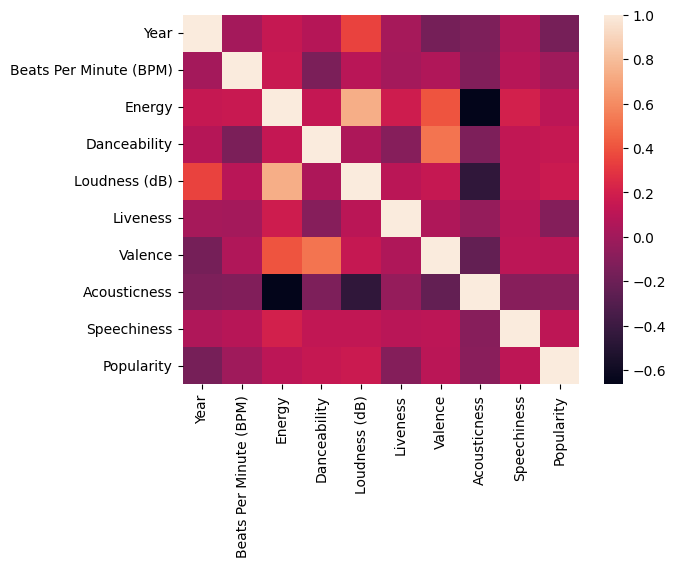

In [13]:
sns.heatmap(df.corr(numeric_only=True))

In [14]:
df.isnull().sum()

,0
Title,0
Artist,0
Top Genre,0
Year,0
Beats Per Minute (BPM),0
Energy,0
Danceability,0
Loudness (dB),0
Liveness,0
Valence,0


In [27]:
df2 = df[["Beats Per Minute (BPM)", "Loudness (dB)",
              "Liveness", "Valence", "Acousticness",
              "Speechiness"]]



In [28]:

from sklearn.preprocessing import MinMaxScaler
for i in df.columns:
    MinMaxScaler(i)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10)
clusters = kmeans.fit_predict(df2)


## Silhouette score gibi test olaylarına girilmesi mantıksız güzel sonuçlar vermez çünkü Müzik türleri net kümeler oluşturmaz

In [29]:
df["Music Segments"] = clusters
MinMaxScaler(df["Music Segments"])
df["Music Segments"] = df["Music Segments"].map({1: "Cluster 1", 2:
    "Cluster 2", 3: "Cluster 3", 4: "Cluster 4", 5: "Cluster 5",
    6: "Cluster 6", 7: "Cluster 7", 8: "Cluster 8",
    9: "Cluster 9", 10: "Cluster 10"})

In [30]:
df.head()

,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity,Cluster,Cluster_Adjusted,Music Segments
0,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71,1,1,Cluster 2
1,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39,8,0,NaN
2,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69,8,0,Cluster 8
3,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76,2,0,Cluster 8
4,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59,6,0,NaN


In [31]:
import plotly.graph_objects as go
PLOT = go.Figure()
for i in list(df["Music Segments"].unique()):


    PLOT.add_trace(go.Scatter3d(x = df[df["Music Segments"]== i]['Beats Per Minute (BPM)'],
                                y = df[df["Music Segments"] == i]['Energy'],
                                z = df[df["Music Segments"] == i]['Danceability'],
                                mode = 'markers',marker_size = 6, marker_line_width = 1,
                                name = str(i)))
PLOT.update_traces(hovertemplate='Beats Per Minute (BPM): %{x} <br>Energy: %{y} <br>Danceability: %{z}')


PLOT.update_layout(width = 800, height = 800, autosize = True, showlegend = True,
                   scene = dict(xaxis=dict(title = 'Beats Per Minute (BPM)', titlefont_color = 'black'),
                                yaxis=dict(title = 'Energy', titlefont_color = 'black'),
                                zaxis=dict(title = 'Danceability', titlefont_color = 'black')),
                   font = dict(family = "Gilroy", color  = 'black', size = 12))